In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Preprocessing 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Machine Learning Models
from xgboost import XGBClassifier           # Supervised
from sklearn.cluster import KMeans, DBSCAN  # Unsupervised
from sklearn.mixture import GaussianMixture 
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator               # find epsilon for DBSCAN

# Metrics and Visualization
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, \
    accuracy_score, classification_report, confusion_matrix, \
        silhouette_score, adjusted_rand_score, davies_bouldin_score
import shap

In [2]:
df_train = pd.read_csv("data/KDDTrain.csv")
df_test = pd.read_csv("data/KDDTest.csv")

## Explore Data

In [3]:
print(df_train.shape, df_test.shape)
print("Missing values:", df_train.isna().sum().sum(), df_test.isna().sum().sum())
print("Attack classes (train, sample):", df_train["attack"].unique())

(125973, 43) (22544, 43)
Missing values: 0 0
Attack classes (train, sample): ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


There are four object columns. Let's look at their categorical data.

In [4]:
# categorical distributions
for col in ["protocol_type", "service", "flag"]:
    vc = df_train[col].value_counts().head(10)
    print(f"\nTop {col} values:\n{vc}")


Top protocol_type values:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

Top service values:
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64

Top flag values:
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64


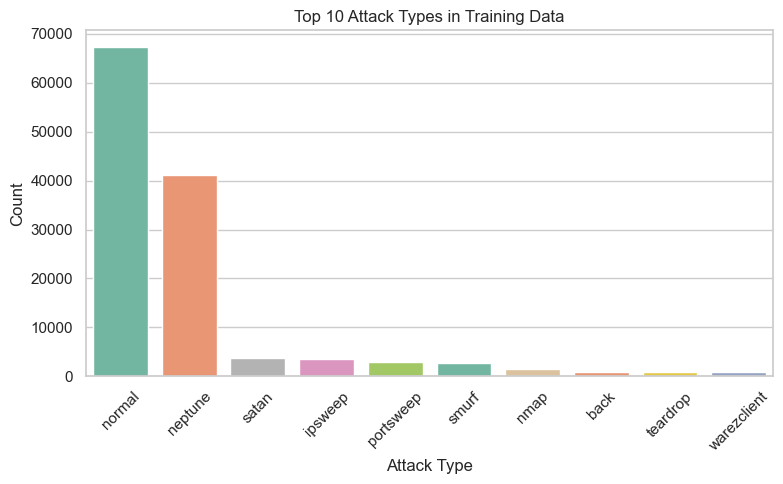

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [5]:
# plot style
sns.set(style="whitegrid")

# get top 10 attack types
top_10_attacks = df_train['attack'].value_counts().head(10).index

# plot
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_train[df_train['attack'].isin(top_10_attacks)],
    x="attack",
    hue="attack",
    palette="Set2",
    order=top_10_attacks
)

plt.title("Top 10 Attack Types in Training Data")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(df_train['attack'].value_counts())

## Feature Engineer

In [6]:
df_train['is_anomalous'] = df_train['attack'].apply(
  lambda x: 0 if x == 'normal' else 1)

df_test['is_anomalous'] = df_test['attack'].apply(
  lambda x: 0 if x == 'normal' else 1)

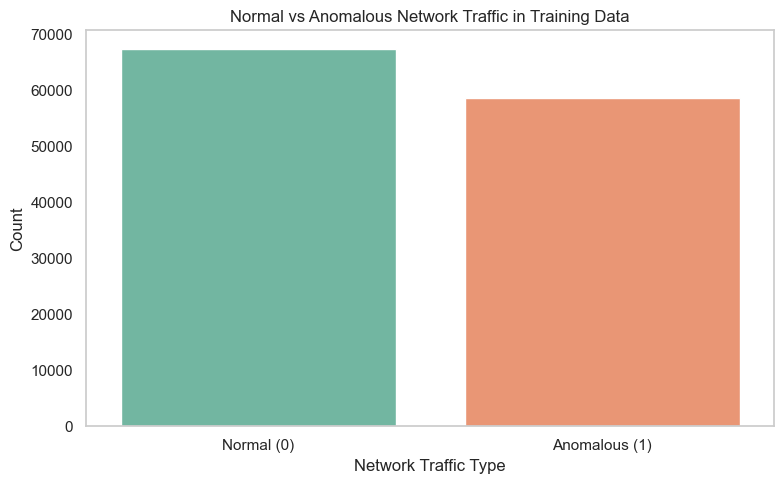

,Count,Percentage
is_anomalous,,
Normal,67343,53.46
Attack,58630,46.54


In [7]:
plt.figure(figsize = (8, 5))

ax = sns.countplot(x = 'is_anomalous', 
                   data = df_train, 
                   palette = "Set2", 
                   hue = "is_anomalous"
                  )
plt.xticks([0, 1], ['Normal (0)', 'Anomalous (1)'])
plt.xlabel('Network Traffic Type')
plt.ylabel('Count')
plt.title('Normal vs Anomalous Network Traffic in Training Data')

ax.legend_.remove()
ax.grid(False, axis = 'y')

plt.tight_layout()
plt.show()

# Create summary table for is_anomalous
value_counts = df_train["is_anomalous"].value_counts()
percentages = (value_counts / value_counts.sum()) * 100

summary_table = pd.DataFrame({
    "Count": value_counts,
    "Percentage": percentages.round(2)
}).rename(index={0: "Normal", 1: "Attack"})

summary_table

## Preprocessing

### Identify Categorical and Numerical Data

In [8]:
'''

Drop unwanted columns:
    - attack: type of network attack
    - level of difficulty of identifying attack
    
'''
# unnessecary columns
drop_cols = ["attack", "level"]
y = ['is_anomalous']

# Identify categorical and numerical features list
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.to_list()
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = [c for c in categorical_cols if c not in drop_cols + y]
numeric_cols = [c for c in numeric_cols if c not in drop_cols + y]

print("Categorical columns:", categorical_cols, "\nNumeric columns:", numeric_cols)
print("Categorical Length:", len(categorical_cols), "\nNumeric Length:", len(numeric_cols))

Categorical columns: ['protocol_type', 'service', 'flag'] 
Numeric columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Categorical Length: 3 
Numeric Length: 38


### Scaling and one-hot encodeing

In [9]:
'''
Scale and One-hot encode
'''
ohe = OneHotEncoder()
scaler = StandardScaler()

df_train_num = scaler.fit_transform(df_train[numeric_cols]).astype(np.float32)
df_test_num  = scaler.transform(df_test[numeric_cols]).astype(np.float32)

df_train_cat = ohe.fit_transform(df_train[categorical_cols])
df_test_cat  = ohe.transform(df_test[categorical_cols])

feature_names = np.concatenate([numeric_cols, ohe.get_feature_names_out(categorical_cols)])

# Combine categorical and numerical data
df_train_encoded = pd.DataFrame(
    np.hstack([df_train_num, df_train_cat.toarray()]),
    columns = feature_names,
    index = df_train.index
)
df_test_encoded = pd.DataFrame(
    np.hstack([df_test_num, df_test_cat.toarray()]),
    columns = feature_names,
    index = df_test.index
)

print("Train Shape:", df_train_encoded.shape, "\nTest Shape:", df_test_encoded.shape)

Train Shape: (125973, 122) 
Test Shape: (22544, 122)


In [10]:
'''
Scaling Check
'''

train_means = df_train_encoded[numeric_cols].mean()
train_stds = df_train_encoded[numeric_cols].std(ddof=0)

test_means = df_test_encoded[numeric_cols].mean()
test_stds = df_test_encoded[numeric_cols].std(ddof=0)

print("\nTrain Set Scaling Check:")
print(f"Max |mean|: {train_means.abs().max():.6f}")
print(f"Max |std - 1|: {(train_stds - 1).abs().max():.6f}")

print("\nTest Set Scaling Check:")
print(f"Max |mean|: {test_means.abs().max():.6f}")
print(f"Max |std - 1|: {(test_stds - 1).abs().max():.6f}")


Train Set Scaling Check:
Max |mean|: 0.000000
Max |std - 1|: 1.000000

Test Set Scaling Check:
Max |mean|: 0.451471
Max |std - 1|: 6.838182


### Feature Selection


#### Variance Threshold

In [11]:
'''
Drop any features with variance equal to or below 0.01
'''

# variance threshhold
var_thresh = 0.01

selector = VarianceThreshold(threshold = var_thresh)
df_train_var = selector.fit_transform(df_train_encoded)
df_test_var  = selector.transform(df_test_encoded)

# kept feature names
kept_features = df_train_encoded.columns[selector.get_support(indices = True)]

# back to DataFrames
df_train_var = pd.DataFrame(df_train_var, columns = kept_features, index = df_train.index)
df_test_var  = pd.DataFrame(df_test_var,  columns = kept_features, index = df_test.index)

# report
num_dropped = df_train_encoded.shape[1] - df_train_var.shape[1]
print(f"Variance threshold = {var_thresh}")
print(f"Features before: {df_train_encoded.shape[1]}")
print(f"Features after:  {df_train_var.shape[1]}")
print(f"Dropped: {num_dropped} features")

# preview
print("\nFirst 10 kept features:")
print(kept_features[:10])

Variance threshold = 0.01
Features before: 122
Features after:  56
Dropped: 66 features

First 10 kept features:
Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised'],
      dtype='object')


#### High-Correlation Feature Pruning

In [12]:
corr_threshold = 0.95  # adjust as needed

# correlation matrix 
corr_matrix = df_train_var.corr().abs()

# features to drop
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > corr_threshold)
]

# drop
df_train_corr = df_train_var.drop(columns=to_drop)
df_test_corr  = df_test_var.drop(columns=to_drop)

print(f"Correlation threshold = {corr_threshold}")
print(f"Features before: {df_train_var.shape[1]}")
print(f"Features after:  {df_train_corr.shape[1]}")
print(f"Dropped: {len(to_drop)} features")

print("\nDropped features due to high correlation:")
print(to_drop)

Correlation threshold = 0.95
Features before: 56
Features after:  49
Dropped: 7 features

Dropped features due to high correlation:
['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'flag_S0']


#### Mutual Information Scores

In [13]:
target_col = "is_anomalous"
neighbors = 7
rng_seed = 42

# combine the data to have a reference
df_train_reduced = pd.concat([df_train_corr.reset_index(drop = True), df_train.loc[df_train_corr.index, ["is_anomalous"]].reset_index(drop = True)], axis = 1)
df_test_reduced = pd.concat([df_test_corr.reset_index(drop = True), df_test.loc[df_test_corr.index, ["is_anomalous"]].reset_index(drop = True)], axis = 1)

# separate features and target
X_full = df_train_reduced.drop(columns=[target_col])
y_full = df_train_reduced[target_col].astype(int)

# compute MI scores
mi_scores = mutual_info_classif(X_full, y_full,
                                discrete_features='auto',
                                n_neighbors=neighbors,
                                random_state=rng_seed)

# store in DataFrame and sort
mi_df = pd.DataFrame({
    "Feature": X_full.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)

# select top 30 features
top_features = mi_df.head(17)


In [14]:
# pretty print table
print("Top 30 Features by Mutual Information:\n")
print(top_features.to_string(index=False))

# create reduced DataFrames for modeling
df_train_top17 = df_train_reduced[top_features["Feature"].tolist() + y]
df_test_top17  = df_test_reduced[top_features["Feature"].tolist() + y]

print(f"\nTrain shape with top 30 features: {df_train_top17.shape}")
print(f"Test shape with top 30 features:  {df_test_top17.shape}")

df_train_EDA = df_train_top17[top_features["Feature"].tolist() + y]
df_test_EDA  = df_test_top17[top_features["Feature"].tolist() + y]

Top 30 Features by Mutual Information:

                    Feature  MI_Score
                  src_bytes  0.564592
                  dst_bytes  0.438462
              diff_srv_rate  0.360036
              same_srv_rate  0.355225
         dst_host_srv_count  0.331552
                    flag_SF  0.330428
     dst_host_same_srv_rate  0.304843
     dst_host_diff_srv_rate  0.285189
                  logged_in  0.283532
                serror_rate  0.276421
                      count  0.265388
dst_host_srv_diff_host_rate  0.189679
               service_http  0.185479
             dst_host_count  0.137209
dst_host_same_src_port_rate  0.132210
            service_private  0.119282
         srv_diff_host_rate  0.100504

Train shape with top 30 features: (125973, 18)
Test shape with top 30 features:  (22544, 18)


Confirm everything is still scaled. 

In [15]:
X_num = df_train_top17.drop(columns=[target_col])
desc = X_num.describe().T[["min", "max", "mean", "std"]]
print(desc.sort_values("std", ascending=False).head(31))


                                  min         max          mean       std
src_bytes                   -0.007762  235.067459  1.394409e-10  1.000004
dst_host_diff_srv_rate      -0.439078    4.854138 -2.108072e-09  1.000004
dst_host_same_srv_rate      -1.161030    1.066401  3.018620e-09  1.000004
dst_host_same_src_port_rate -0.480197    2.756092  1.234607e-08  1.000004
dst_host_count              -1.836071    0.734343  8.007745e-09  1.000004
serror_rate                 -0.637209    1.602664 -2.351370e-08  1.000004
count                       -0.734511    3.728053 -5.835707e-09  1.000004
same_srv_rate               -1.503403    0.771283 -1.697443e-08  1.000004
logged_in                   -0.809262    1.235694  1.928198e-08  1.000004
diff_srv_rate               -0.349683    5.196208  9.552657e-09  1.000004
srv_diff_host_rate          -0.374560    3.474118  2.159305e-09  1.000004
dst_host_srv_count          -1.044721    1.258754 -7.055719e-09  1.000004
dst_bytes                   -0.004919 

Everything is still scaled. This is the feature set we will use to model.

### Proposed Feature Set for Supervised and Unsupervised Learning 

DataFrames: df_train_top17 and df_test_top17.

| Column Name                  | Data Type | Description                                                   | Notes                        |
|-------------------------------|-----------|---------------------------------------------------------------|------------------------------|
| `src_bytes`                   | int64     | Number of data bytes sent from source to destination.          | Numeric (scaled)             |
| `dst_bytes`                   | int64     | Number of data bytes sent from destination to source.          | Numeric (scaled)             |
| `count`                       | int64     | Number of connections to the same host in the past 2 seconds.  | Numeric (scaled)             |
| `srv_diff_host_rate`          | float64   | % of connections to different hosts on the same service.       | Numeric (scaled)             |
| `serror_rate`                 | float64   | % of connections with SYN errors.                              | Numeric (scaled)             |
| `same_srv_rate`               | float64   | % of connections to the same service.                          | Numeric (scaled)             |
| `diff_srv_rate`               | float64   | % of connections to different services.                        | Numeric (scaled)             |
| `dst_host_count`              | int64     | Number of connections to the destination host.                 | Numeric (scaled)             |
| `dst_host_srv_count`          | int64     | Number of connections to the destination host and service.     | Numeric (scaled)             |
| `dst_host_same_srv_rate`      | float64   | % of connections to the same service on the destination host.  | Numeric (scaled)             |
| `dst_host_diff_srv_rate`      | float64   | % of connections to different services on the destination host.| Numeric (scaled)             |
| `dst_host_same_src_port_rate` | float64   | % of connections from the same source port.                    | Numeric (scaled)             |
| `dst_host_srv_diff_host_rate` | float64   | % of connections to the same service from different hosts.     | Numeric (scaled)             |
| `logged_in`                   | int64     | 1 if successfully logged in; 0 otherwise.                      | Binary indicator             |
| `flag_SF`                     | int64     | One-hot encoded: Status flag "SF" of the connection.           | One-hot encoded categorical  |
| `service_http`                | int64     | One-hot encoded: Network service is HTTP.                      | One-hot encoded categorical  |
| `service_private`             | int64     | One-hot encoded: Network service is "private".                 | One-hot encoded categorical  |
| `is_anomalous`                | int64     | Target: 1 if connection is anomalous; 0 if normal.             | Target variable              |



### Visualizations

#### Correlation Heatmap

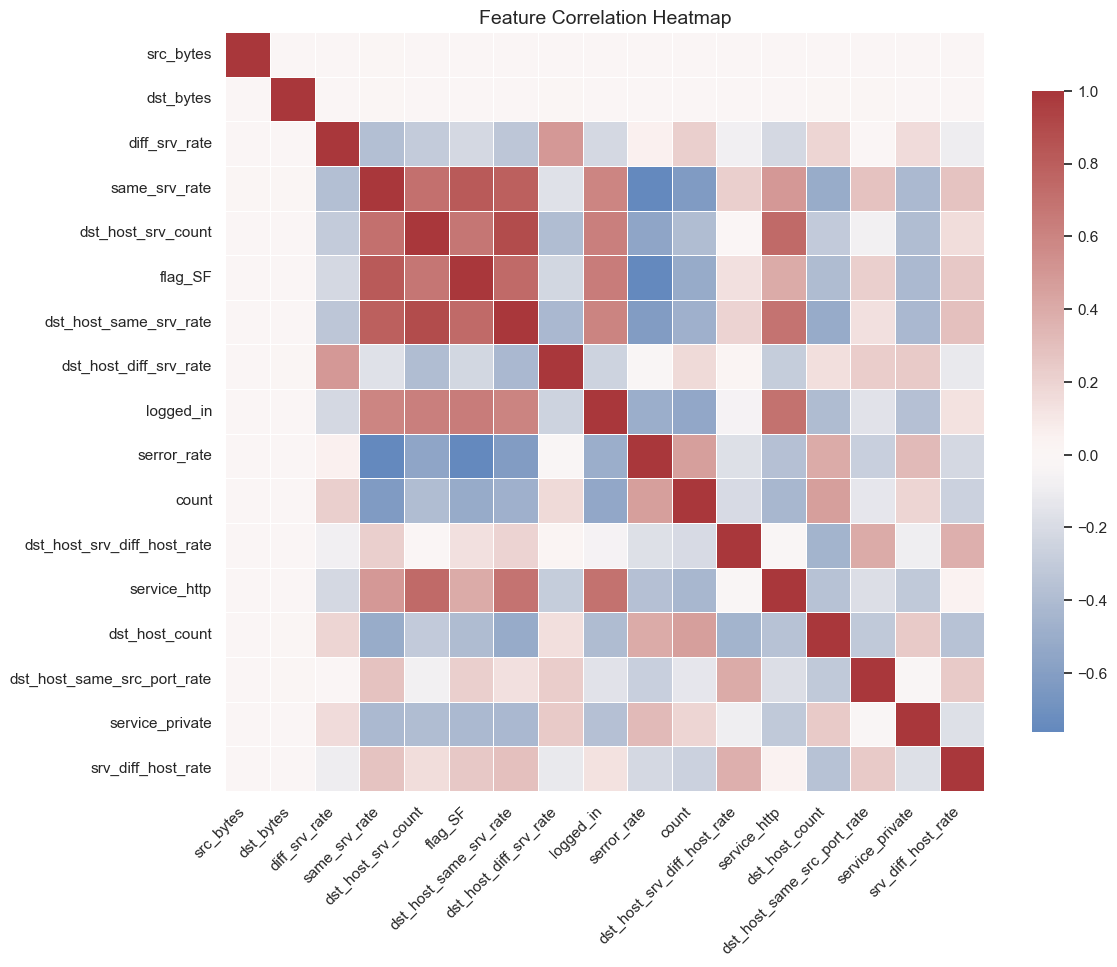

In [16]:

X_top30 = df_train_top17.drop(columns=[target_col])

# compute correlation matrix
corr = X_top30.corr(method="pearson")

# plot style
sns.set_theme(style="white")

# heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="vlag",
    linewidths=0.5,
    annot=False,
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### MI Information Bar Plot

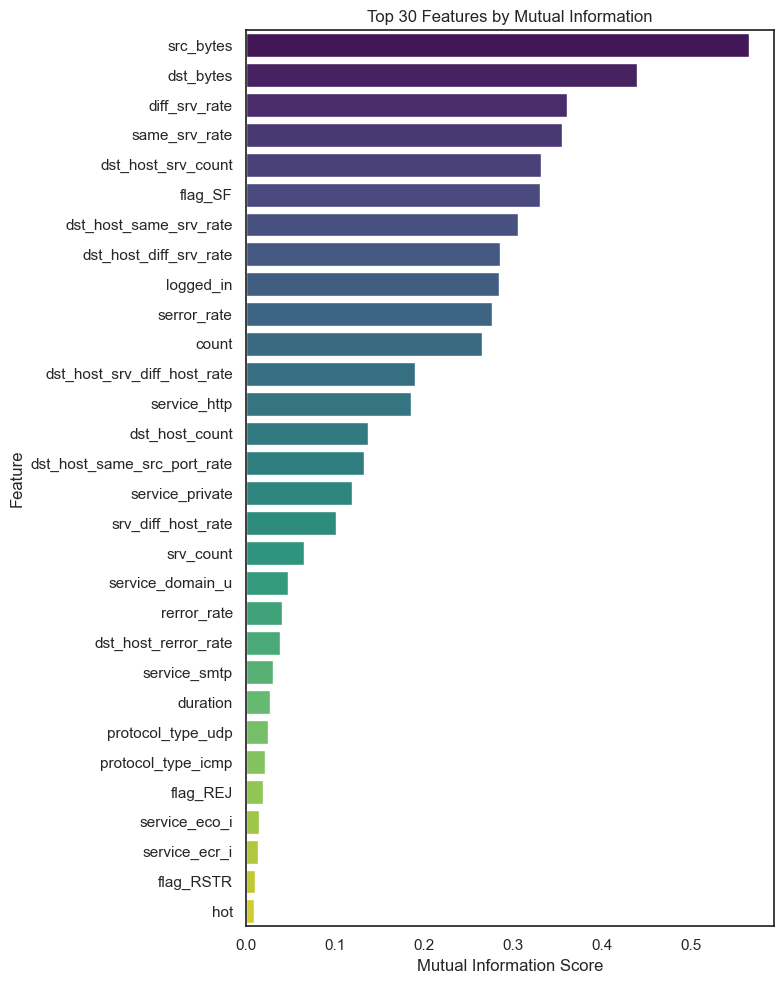

In [17]:
plt.figure(figsize=(8, 10))
sns.barplot( data=mi_df.head(30), x="MI_Score", y="Feature", palette="viridis", hue = "Feature")
plt.title("Top 30 Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### PCA Projection

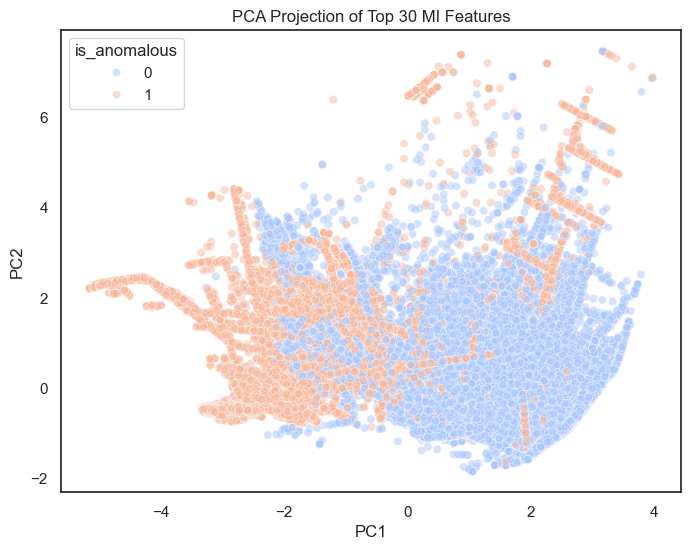

In [18]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2, random_state=42).fit_transform(
    df_train_top17.drop(columns=[target_col])
)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df[target_col] = df_train_top17[target_col].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue=target_col,
    palette="coolwarm",
    alpha=0.5
)
plt.title("PCA Projection of Top 30 MI Features")
plt.show()

## Machine Learning Models

In [19]:
'''
Shared between both models

X and y (train and test)
'''

X_train = df_train_EDA.drop(columns=['is_anomalous'])
y_train = df_train_EDA['is_anomalous']

X_test = df_test_EDA.drop(columns=['is_anomalous'])
y_test = df_test_EDA['is_anomalous']

### Supervised Model and tune

In [20]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Computed scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    'n_estimators': [330, 340, 350],
    'max_depth': [13, 14, 15],
    'learning_rate': [0.050, 0.055, 0.1],
    'subsample': [0.93, 0.95, 0.97],
    'colsample_bytree': [0.60, 0.625, 0.65],
    'gamma': [0.04, 0.05, 0.06],
    'reg_alpha': [2.5, 2.75, 3.0],
    'reg_lambda': [2.25, 2.5, 2.75]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1 = make_scorer(f1_score, average='binary')

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=3,
    scoring=f1,
    cv=cv,
    verbose=3,
    random_state=42,
    n_jobs=1
)

search.fit(X_train, y_train)

print("Best F1 score:", search.best_score_)
print("Best params:", search.best_params_)

Computed scale_pos_weight: 1.15
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5] END colsample_bytree=0.6, gamma=0.05, learning_rate=0.05, max_depth=14, n_estimators=340, reg_alpha=3.0, reg_lambda=2.5, subsample=0.97;, score=0.998 total time=   1.4s
[CV 2/5] END colsample_bytree=0.6, gamma=0.05, learning_rate=0.05, max_depth=14, n_estimators=340, reg_alpha=3.0, reg_lambda=2.5, subsample=0.97;, score=0.998 total time=   1.1s
[CV 3/5] END colsample_bytree=0.6, gamma=0.05, learning_rate=0.05, max_depth=14, n_estimators=340, reg_alpha=3.0, reg_lambda=2.5, subsample=0.97;, score=0.998 total time=   1.1s
[CV 4/5] END colsample_bytree=0.6, gamma=0.05, learning_rate=0.05, max_depth=14, n_estimators=340, reg_alpha=3.0, reg_lambda=2.5, subsample=0.97;, score=0.998 total time=   1.1s
[CV 5/5] END colsample_bytree=0.6, gamma=0.05, learning_rate=0.05, max_depth=14, n_estimators=340, reg_alpha=3.0, reg_lambda=2.5, subsample=0.97;, score=0.998 total time=   1.1s
[CV 1/5] END colsa

#### Predict Against Test Set

Test Accuracy: 0.778388928317956
Test ROC AUC: 0.963783985241748
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



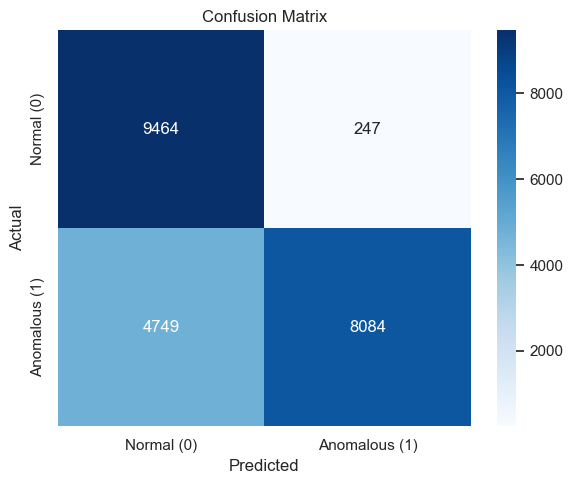

In [21]:

y_pred = search.best_estimator_.predict(X_test)
y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]


print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
labels = ['Normal (0)', 'Anomalous (1)']

# Heatmap version
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### SHAP Visualization of Feature Importance

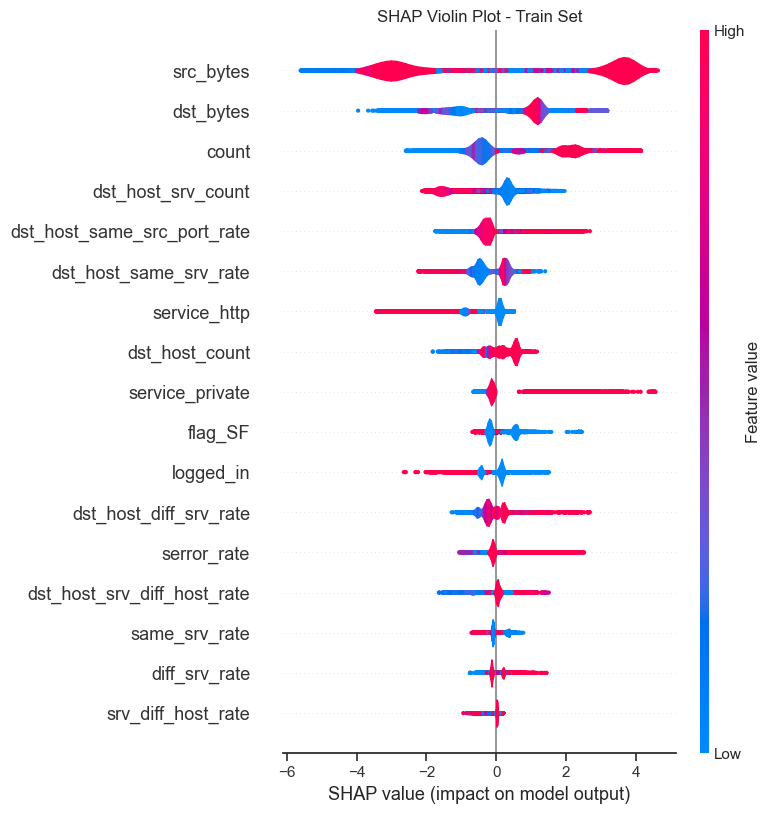

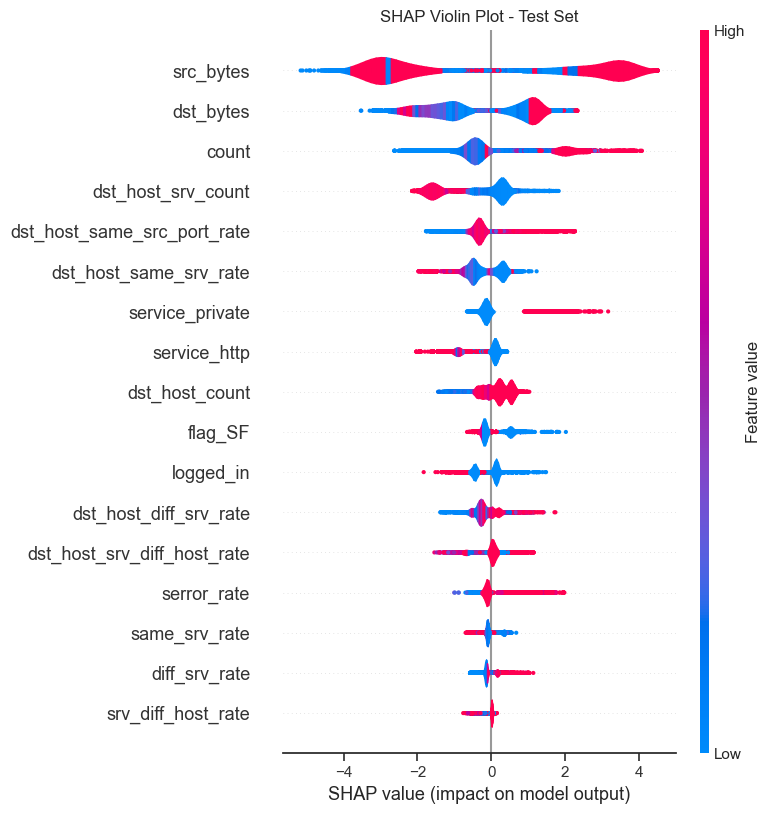

In [22]:

explainer = shap.TreeExplainer(search.best_estimator_)

# Compute SHAP values for training and test sets
shap_values_train = explainer.shap_values(X_train)
shap_values_test = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values_train,
    X_train,
    plot_type="violin",
    show=False
)
plt.title("SHAP Violin Plot - Train Set")
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values_test,
    X_test,
    plot_type="violin",
    show=False
)
plt.title("SHAP Violin Plot - Test Set")
plt.tight_layout()
plt.show()

#### Missed vs. Accurate Predictions

In [23]:
df_test_EDA["difficulty_level"] = df_test.loc[df_test_EDA.index, "level"]

missing = df_test_EDA.index.difference(df_test.index)
print(f"Missing indexes from df_test: {len(missing)}")

same_order = (df_test_EDA.index == df_test.loc[df_test_EDA.index].index).all()
print(f"Indexes in same order: {same_order}")


Missing indexes from df_test: 0
Indexes in same order: True


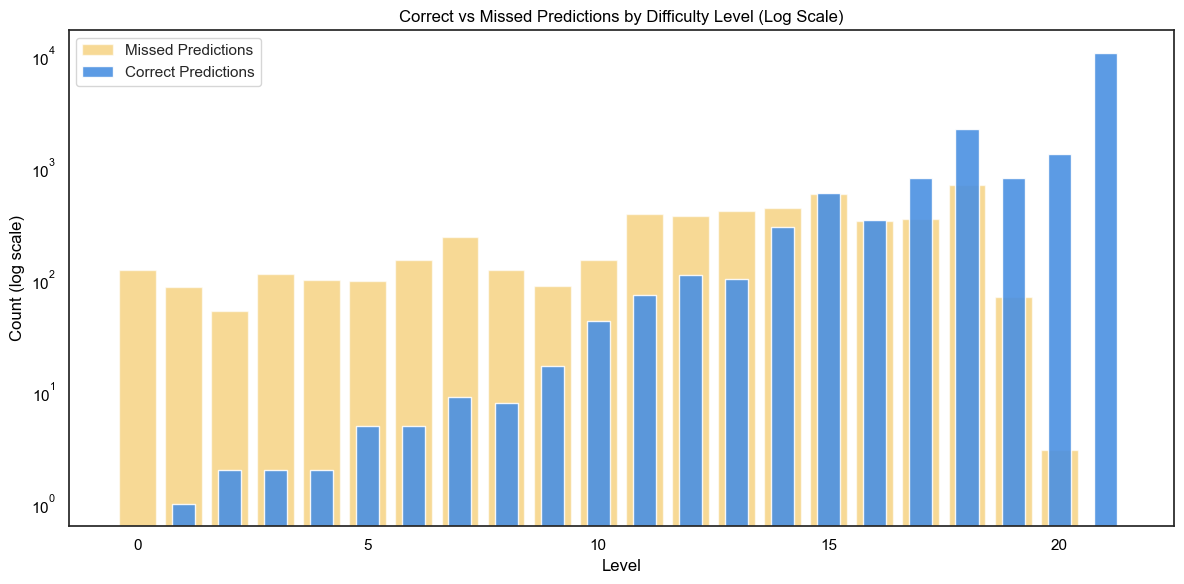

In [24]:

# Ensure df_test_EDA has level info
df_test_EDA = df_test_EDA.copy()
df_test_EDA["difficulty_level"] = df_test.loc[df_test_EDA.index, "level"]

# Build test dataframe
df_test = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "level": df_test_EDA["difficulty_level"].values
})

# Add correct column
df_test["correct"] = df_test["y_true"] == df_test["y_pred"]

# Group by level
level_stats = (
    df_test
    .groupby("level")
    .agg(
        correct_count = ("correct", lambda x: x.sum()),
        missed_count = ("correct", lambda x: (~x).sum())
    )
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize = (12, 6))

# Missed predictions
ax.bar(
    level_stats["level"],
    level_stats["missed_count"],
    label = "Missed Predictions",
    color = "#f2c14e",  # goldenrod
    width = 0.8,
    alpha = 0.6
)

# Correct predictions
ax.bar(
    level_stats["level"],
    level_stats["correct_count"],
    label = "Correct Predictions",
    color = "#4a90e2",  # blue
    width = 0.5,
    alpha = 0.9
)

# Log scale for shared y-axis
ax.set_yscale("log")

# Labels and title
ax.set_xlabel("Level", color = "black")
ax.set_ylabel("Count (log scale)", color = "black")
ax.set_title("Correct vs Missed Predictions by Difficulty Level (Log Scale)", color = "black")
ax.tick_params(axis = "x", colors = "black")
ax.tick_params(axis = "y", colors = "black")

# Legend
ax.legend(loc = "upper left", frameon = True)

plt.tight_layout()
plt.show()


### Unsupervised Learning Model

#### Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

Suggested eps: 2.938


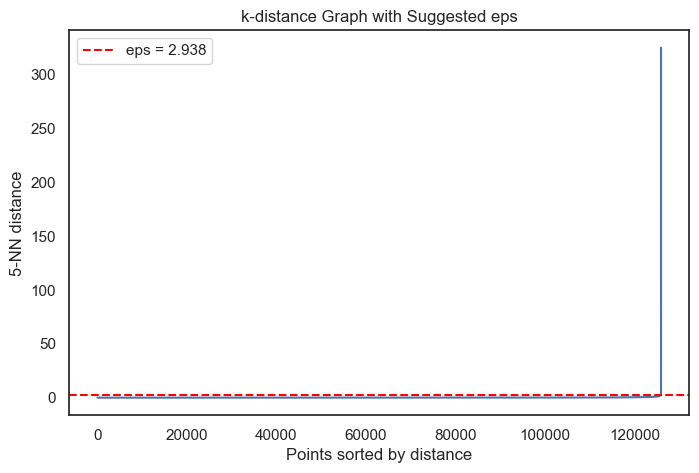

In [ ]:
'''
For DBSCAN
Choosing epsilon

using elbow method
'''

min_samples = 5  # same as you plan to use in DBSCAN
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_train)
distances, indices = neighbors_fit.kneighbors(X_train)

# Take the k-th NN distance
distances = np.sort(distances[:, -1])  

# Find the elbow
kneedle = KneeLocator(range(len(distances)), distances, curve="convex", direction="increasing")
optimal_eps = distances[kneedle.knee]


plt.figure(figsize=(8,5))
plt.plot(distances)
plt.axhline(y=optimal_eps, color="red", linestyle="--", label=f"eps = {optimal_eps:.3f}")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("k-distance Graph with Suggested eps")
plt.legend()
plt.show()

print(f"Suggested eps: {optimal_eps:.3f}")

In [26]:
'''
DBSCAN
'''
set_eps = 0.8
dbscan = DBSCAN(eps=set_eps, min_samples=5)
# Prediction
dbscan_labels = dbscan.fit_predict(X_train)

In [27]:
'''
Prediction Results

Silhouette Score explanation
    -> https://www.geeksforgeeks.org/machine-learning/what-is-silhouette-score/
'''
dbscan_silhouette = silhouette_score(X_train, dbscan_labels, random_state=1)

print("DBSCAN Epsilon:", set_eps)
print("DBSCAN Clusters:", set(dbscan_labels))
print("DBSCAN Silhouette Score:", dbscan_silhouette
      if len(set(dbscan_labels)) > 1 else "N/A")

DBSCAN Epsilon: 0.8
DBSCAN Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int

#### K-Means Clustering

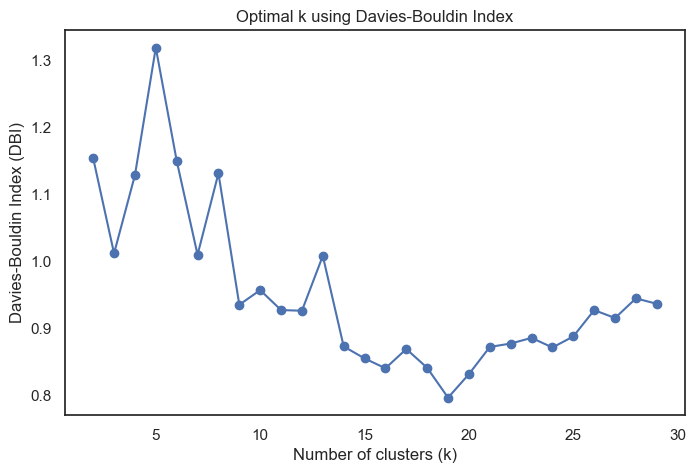

Optimal number of clusters (lowest DBI): 19


In [28]:
'''
Choosing K-clusters

Important: must scale data

Using Davies-Bouldin Index
'''

k_values = range(2, 30)
dbi_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=10)
    labels = kmeans.fit_predict(X_train)   # Use scaled/encoded features
    dbi = davies_bouldin_score(X_train, labels)
    dbi_scores.append(dbi)

# Plot DBI
plt.figure(figsize=(8, 5))
plt.plot(k_values, dbi_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index (DBI)")
plt.title("Optimal k using Davies-Bouldin Index")
plt.show()

best_k = k_values[dbi_scores.index(min(dbi_scores))]
print(f"Optimal number of clusters (lowest DBI): {best_k}")

In [ ]:
'''
K-Means Clustering
''' 

kmeans = KMeans(n_clusters=best_k, random_state=1, n_init=10)
# Prediction
kmeans_labels = kmeans.fit_predict(X_train)

In [30]:
'''
Prediction Results
'''
kmeans_silhouette = silhouette_score(X_train, kmeans_labels, random_state=1)
print("KMeans Inertia:", kmeans.inertia_)
print("KMeans Silhouette Score:", kmeans_silhouette)

KMeans Inertia: 249999.30905752297
KMeans Silhouette Score: 0.41426751982683147


#### Soft Clustering

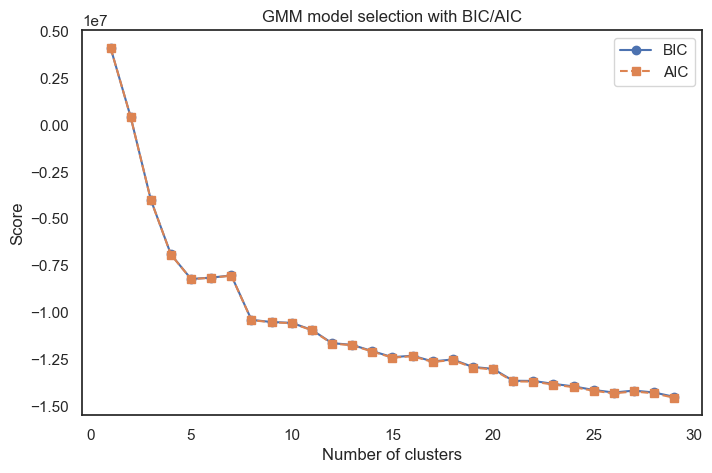

Optimal number of clusters (BIC): 29


In [31]:
'''
Find Best n for GMM
'''

n_components = range(1, 30)
bics = []
aics = []

for n in n_components:
    gmm = GaussianMixture(n_components=n, 
                          covariance_type='full', 
                          random_state=1)
    gmm.fit(X_train)
    bics.append(gmm.bic(X_train))
    aics.append(gmm.aic(X_train))

# Plot BIC and AIC
plt.figure(figsize=(8, 5))
plt.plot(n_components, bics, marker='o', label="BIC")
plt.plot(n_components, aics, marker='s', label="AIC", linestyle="--")
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.title("GMM model selection with BIC/AIC")
plt.legend()
plt.show()

# Best n_clusters
best_n = n_components[np.argmin(bics)]
print("Optimal number of clusters (BIC):", best_n)

In [ ]:
'''
Soft Clustering
Gaussian Mixture Models (GMM)
based on probability distributions
'''

gmm = GaussianMixture(n_components = best_n, 
                      covariance_type = 'full', 
                      random_state = 0)

# Predict soft assignments
gmm_labels = gmm.fit_predict(X_train)


In [37]:
'''
GMM Metrics
'''
# Predict soft assignments
probs = gmm.predict_proba(X_train)

# Assign each data point to the cluster with the highest probability
hard_assignments = np.argmax(probs, axis=1)

# Calculate the silhouette score using these hard assignments
gmm_silhouette = silhouette_score(X_train, hard_assignments, random_state=1)

print(f"Average silhouette score for GMM clustering is: {gmm_silhouette:.3f}")

# BIC
bic_score = gmm.bic(X_train)
print(f"BIC Score: {bic_score:.3f}")

# Convergence
print(f"Converged: {gmm.converged_}")

# Number of iterations
print(f"Number of iterations: {gmm.n_iter_}")

# Cluster weights
print(f"Cluster Weights: {gmm.weights_}")

Average silhouette score for GMM clustering is: 0.307
BIC Score: -14494533.421
Converged: True
Number of iterations: 41
Cluster Weights: [3.33901886e-02 8.89795095e-02 9.21080112e-02 2.82282711e-02
 1.48841276e-02 5.20136320e-02 7.93820898e-06 1.96855283e-02
 1.58764180e-05 5.61327454e-02 1.45664228e-02 5.19924698e-02
 3.06276380e-02 5.22593427e-02 2.57048008e-02 9.58318073e-03
 2.38146269e-05 1.58764180e-05 4.55624762e-03 8.93401549e-03
 1.40351874e-01 2.21067998e-02 1.54294993e-01 1.72366187e-02
 2.47055959e-02 6.54053309e-03 2.29213618e-02 4.11953659e-03
 2.40130499e-02]


#### Comparing Unsupervised Learning Results

In [38]:
'''
Silhouette Score
'''
print("Comparing silhouette scores: ")
print(f"DBSCAN: {dbscan_silhouette:.3f}")
print(f"KMeans clustering : {kmeans_silhouette:.3f}")
print(f"GMM clustering: {gmm_silhouette:.3f}")

'''
Compare clustering with true labels
adjusted rand index (ARI)
'''
print("\nComparing Adjusted Rand Index:")
print("DBSCAN ARI:", adjusted_rand_score(y_train, dbscan_labels))
print("KMeans ARI:", adjusted_rand_score(y_train, kmeans_labels))
print("GMM ARI:", adjusted_rand_score(y_train, gmm_labels))

Comparing silhouette scores: 
DBSCAN: 0.114
KMeans clustering : 0.414
GMM clustering: 0.307

Comparing Adjusted Rand Index:
DBSCAN ARI: 0.24221704799207797
KMeans ARI: 0.17869312477322208
GMM ARI: 0.1433135299744891


#### Visualize Unsupervised Learning Results

In [39]:
pca = PCA(n_components = 2)
network_pca = pca.fit_transform(X_train)

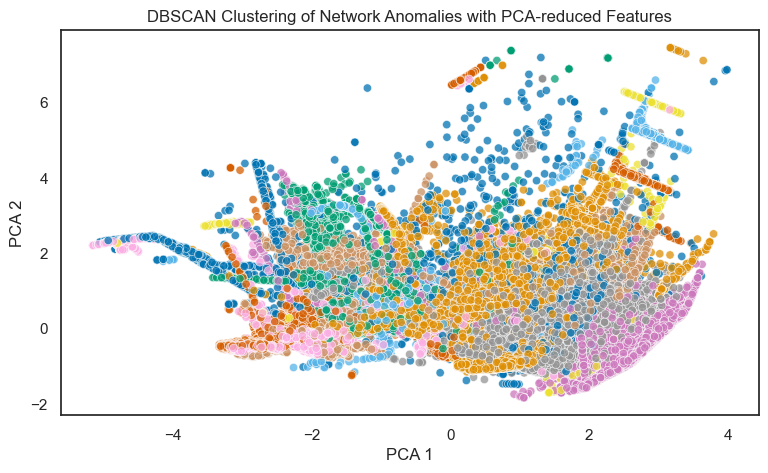

In [44]:
'''
DBSCAN
'''

# Visualize the clusters
plt.figure(figsize = (9, 5))
sns.scatterplot(x = network_pca[:, 0], 
                y = network_pca[:, 1], 
                hue = dbscan_labels, 
                palette = "colorblind", 
                alpha = 0.75, 
                legend = False
                )
plt.title('DBSCAN Clustering of Network Anomalies with PCA-reduced Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

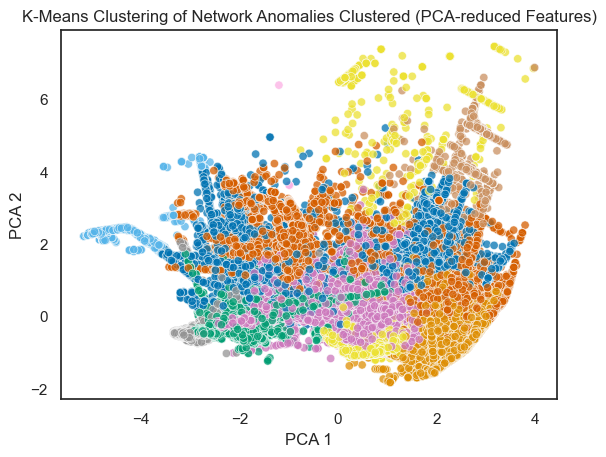

In [46]:
'''
KMeans Clustering
'''
clusters = kmeans.predict(X_train)

sns.scatterplot(x = network_pca[:, 0], 
                y = network_pca[:, 1], 
                hue = clusters, 
                alpha = 0.75, 
                palette = "colorblind",
                legend = False
                )
plt.title('K-Means Clustering of Network Anomalies Clustered (PCA-reduced Features)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

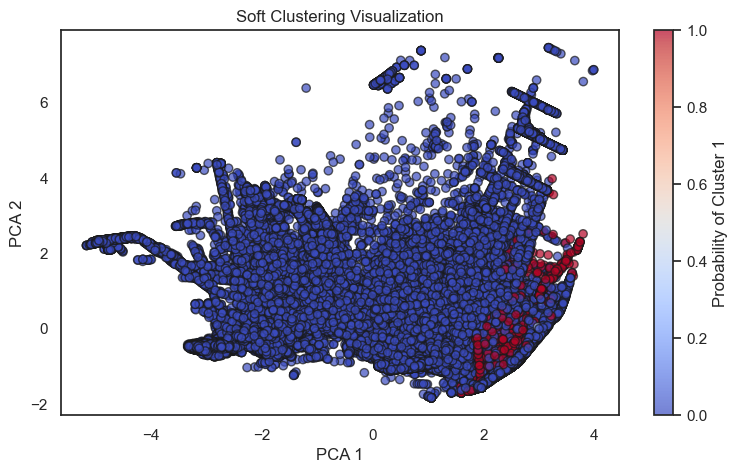

In [ ]:
'''
GMM
'''
# Predict soft assignments
probs = gmm.predict_proba(X_train)

# Choose a cluster to visualize its probability distribution
plt.figure(figsize = (9, 5))
plt.scatter(x=network_pca[:, 0], 
            y=network_pca[:, 1], 
            c = probs[:, 0], 
            cmap = 'coolwarm', 
            edgecolor = 'k', 
            alpha = 0.7
            )
plt.colorbar(label = 'Probability of Cluster 1')
plt.title('Soft Clustering Visualization')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

#### Feature Importance for Unsupervised Learning

In [ ]:
'''
Top 5 Feature Importance for K-Means Clustering Model

Estimated by the variance of each feature's mean across clusters.
Features with largest variation in cluster centers are most influential.
'''

cluster_centers = kmeans.cluster_centers_  # shape: (n_clusters, n_features)
feature_names = X_train.columns

# Standard deviation of each feature across cluster centers
kmeans_feature_importance = np.std(cluster_centers, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': kmeans_feature_importance
}).sort_values(by='Importance', ascending=False)

# Display top 5 features
print("Top 5 K-Means Feature Importances:")
print(importance_df.head(5))

Top 5 K-Means Feature Importances:
                        Feature  Importance
1                     dst_bytes   74.869696
0                     src_bytes   51.907870
11  dst_host_srv_diff_host_rate    2.003900
2                 diff_srv_rate    1.520453
7        dst_host_diff_srv_rate    1.456444


In [ ]:
'''
Top 5 Feature Importance for GMM Model

Identify the most influential features.
The features with the largest variation in means across clusters.

'''

feature_names = X_train.columns

# means for each cluster/component
gmm_means = gmm.means_  # shape: (n_components, n_features)

# standard deviation of means for each feature across clusters
feature_importance = np.std(gmm_means, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# top 5 features
print("Top 5 GMM Feature Importances:")
print(importance_df.head(5))

Top 5 GMM Feature Importances:
                        Feature  Importance
1                     dst_bytes   61.527790
0                     src_bytes   42.739940
11  dst_host_srv_diff_host_rate    1.459121
7        dst_host_diff_srv_rate    1.325182
2                 diff_srv_rate    1.198797
